### Starting Homework 2

##### Downloading the dataset first

In [1]:
!curl -O https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  620k  100  620k    0     0  4219k      0 --:--:-- --:--:-- --:--:-- 4248k


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

In [6]:
df[base].isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
df.horsepower.median()

np.float64(254.0)

##### Check for Longtail

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

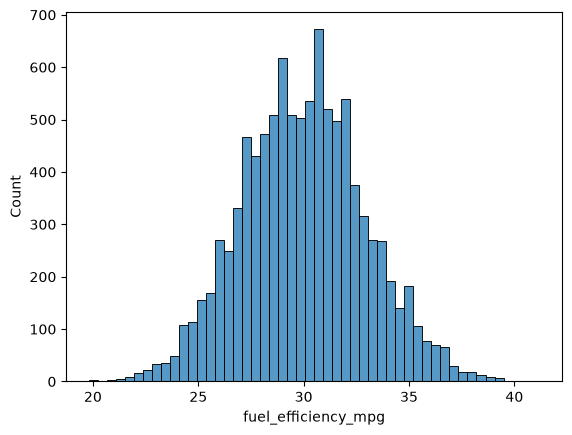

In [9]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

##### Splitting the data as instructed in the lecture

In [8]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [12]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [10]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [26]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [11]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [27]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + df_val[base].fillna(0).values.dot(w)

In [29]:
np.round(rmse(y_val, y_pred) , 3)

np.float64(0.071)

In [30]:
X_train = df_train[base].fillna(df.horsepower.mean()).values
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + df_val[base].fillna(0).values.dot(w)

In [31]:
np.round(rmse(y_val, y_pred) , 3)

np.float64(0.072)

#### Q4

In [33]:
X_train = df_train[base].fillna(0).values

In [34]:
df_train[base].head()

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.0,3790,2015
4684,2000,224.0,4380,1992
1731,2330,286.0,4090,2022
4742,2300,NaN,4150,1997
4521,2340,269.0,4400,2001


In [35]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [39]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = df_train[base].fillna(0).values
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = df_val[base].fillna(0).values
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, round(w0, 4), round(score, 4))

0 -2.5489 0.0715
0.01 -2.4565 0.0715
0.1 -1.8524 0.0717
1 -0.5355 0.0727
5 -0.1287 0.0733
10 -0.066 0.0734
100 -0.0068 0.0735


#### Q5

In [60]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [61]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [62]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
rmse_scores = []
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    X_train = df_train[base].fillna(0).values
    w0, w = train_linear_regression(X_train, y_train)

    X_val = df_val[base].fillna(0).values
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    rmse_scores.append(score)
    print(seed, round(w0, 3), round(score, 3))


0 -150.429 2.239
1 -151.612 2.202
2 -152.841 2.163
3 -152.333 2.204
4 -158.889 2.202
5 -151.857 2.246
6 -154.372 2.27
7 -155.018 2.191
8 -150.438 2.217
9 -154.36 2.207


In [63]:
np.round(np.std(rmse_scores), 4)

np.float64(0.0288)

##### Q6

In [64]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [70]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
rmse_scores = []
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

X_train = pd.concat([df_train[base], df_val[base]]).fillna(0).values
y_full_train = np.concatenate([y_train, y_val])
w0, w =  train_linear_regression_reg(X_train, y_full_train, r=0.001)

X_test = df_test[base].fillna(0).values
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
np.round(score,3)

np.float64(2.236)